In [20]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load saved model results
with open("results_fair.json") as f: fair = json.load(f)
with open("results_measurement.json") as f: measurement = json.load(f)
with open("results_representation.json") as f: representation = json.load(f)
with open("results_realistic.json") as f: realistic = json.load(f)


results = {
    "Fair": fair,
    "MeasurementBias": measurement,
    "RepresentationBias": representation,
    "Realistic": realistic
}


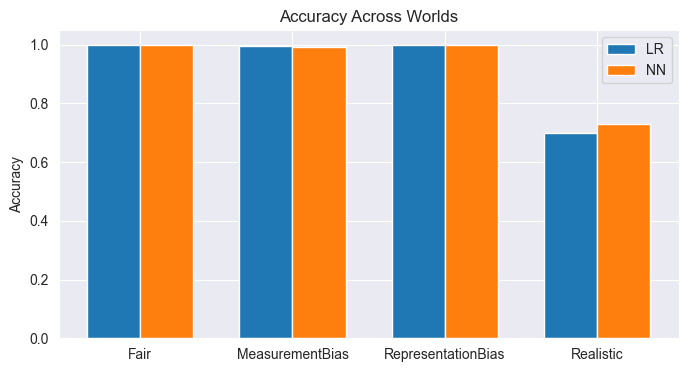

In [21]:
worlds = list(results.keys())
lr_acc = [results[w]["LR_accuracy"] for w in worlds]
mlp_acc = [results[w]["MLP_accuracy"] for w in worlds]

x = np.arange(len(worlds))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, lr_acc, width, label="LR")
plt.bar(x + width/2, mlp_acc, width, label="NN")
plt.xticks(x, worlds)
plt.ylabel("Accuracy")
plt.title("Accuracy Across Worlds")
plt.legend()
plt.show()


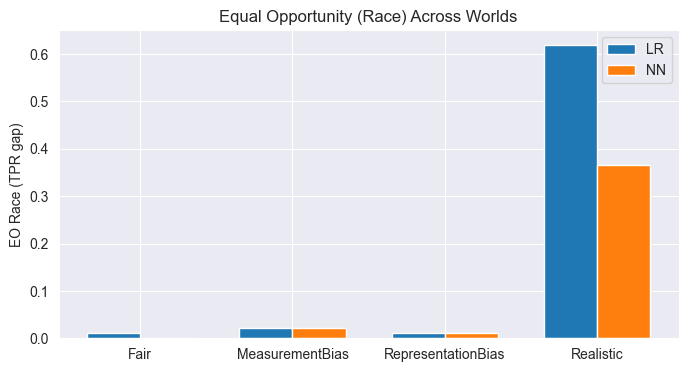

In [24]:
lr_eo_race = [results[w]["LR_EO_race"] for w in worlds]
mlp_eo_race = [results[w]["MLP_EO_race"] for w in worlds]

plt.figure(figsize=(8,4))
plt.bar(x - width/2, lr_eo_race, width, label="LR")
plt.bar(x + width/2, mlp_eo_race, width, label="NN")
plt.xticks(x, worlds)
plt.ylabel("EO Race (TPR gap)")
plt.title("Equal Opportunity (Race) Across Worlds")
plt.legend()
plt.show()


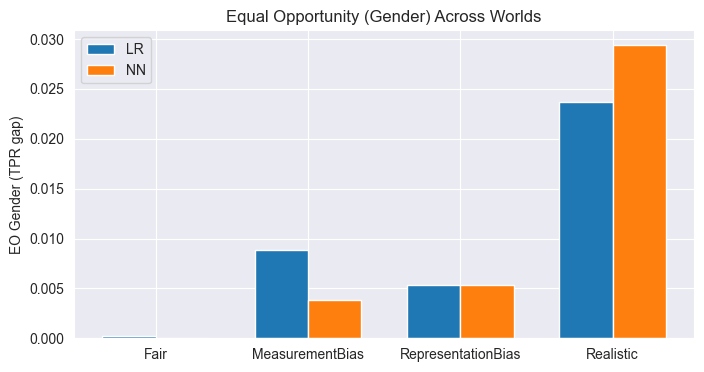

In [25]:
lr_eo_gender = [results[w]["LR_EO_gender"] for w in worlds]
mlp_eo_gender = [results[w]["MLP_EO_gender"] for w in worlds]

plt.figure(figsize=(8,4))
plt.bar(x - width/2, lr_eo_gender, width, label="LR")
plt.bar(x + width/2, mlp_eo_gender, width, label="NN")
plt.xticks(x, worlds)
plt.ylabel("EO Gender (TPR gap)")
plt.title("Equal Opportunity (Gender) Across Worlds")
plt.legend()
plt.show()


In [28]:
df_real = pd.read_csv("df_realistic.csv")  # or df_real.csv


In [41]:
tpr_realistic = pd.read_json("realistic_tpr_by_race.json", orient="index")
tpr_fair = pd.read_json("fair_tpr_by_race.json", orient="index")


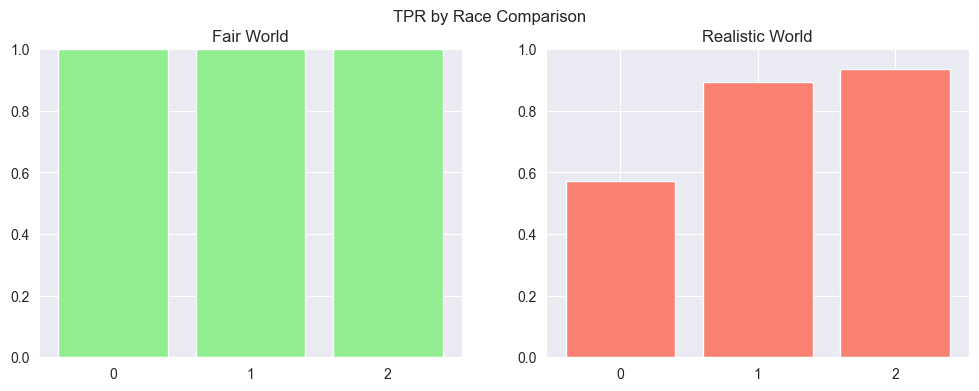

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# Fair
ax[0].bar(tpr_fair.index.astype(str), tpr_fair["TPR"], color="lightgreen")
ax[0].set_title("Fair World")
ax[0].set_ylim(0, 1)

# Realistic
ax[1].bar(tpr_realistic.index.astype(str), tpr_realistic["TPR"], color="salmon")
ax[1].set_title("Realistic World")
ax[1].set_ylim(0, 1)

plt.suptitle("TPR by Race Comparison")
plt.show()


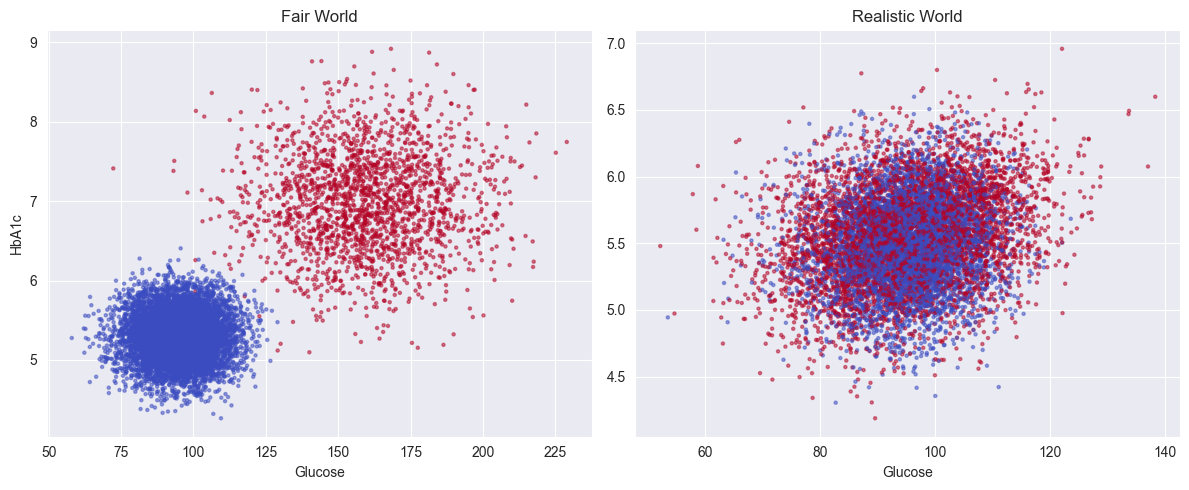

In [46]:
df_fair = pd.read_csv("df_fair.csv")
df_real = pd.read_csv("df_realistic.csv")

plt.figure(figsize=(12,5))

# ----- Fair World -----
plt.subplot(1,2,1)
plt.scatter(
    df_fair["glucose_measured"],
    df_fair["hba1c_measured"],
    c=df_fair["diabetes_label"],   # <-- color by label
    cmap="coolwarm",
    s=5, alpha=0.5
)
plt.title("Fair World")
plt.xlabel("Glucose")
plt.ylabel("HbA1c")

# ----- Realistic World -----
plt.subplot(1,2,2)
plt.scatter(
    df_real["glucose_measured"],
    df_real["hba1c_measured"],
    c=df_real["diabetes_label"],   # <-- color by label
    cmap="coolwarm",
    s=5, alpha=0.5
)
plt.title("Realistic World")
plt.xlabel("Glucose")

plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

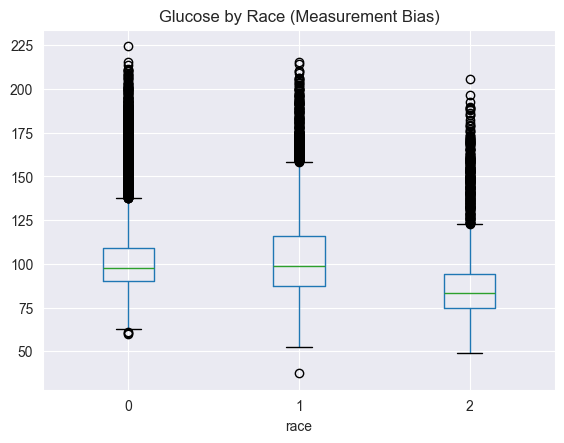

In [31]:
df_measure = pd.read_csv("df_measurement.csv")

plt.figure(figsize=(8,5))
df_measure.boxplot(column="glucose_measured", by="race")
plt.title("Glucose by Race (Measurement Bias)")
plt.suptitle("")
plt.show()


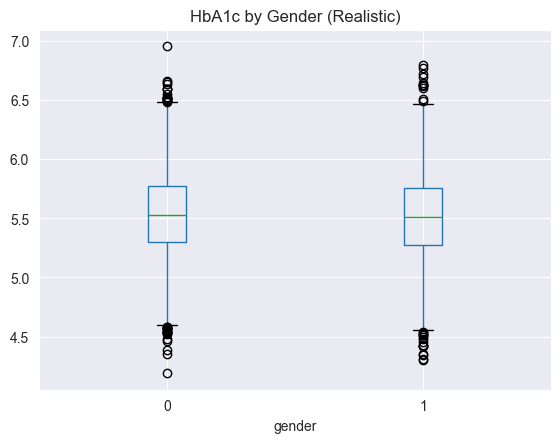

In [32]:
df_real.boxplot(column="hba1c_measured", by="gender")
plt.title("HbA1c by Gender (Realistic)")
plt.suptitle("")
plt.show()


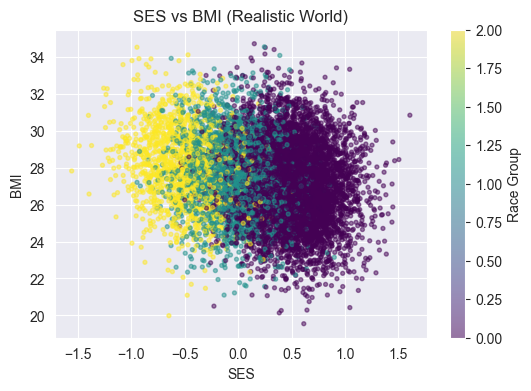

In [45]:
plt.figure(figsize=(6,4))
plt.scatter(
    df_real["ses"],
    df_real["bmi"],
    c=df_real["race"],
    cmap="viridis",
    alpha=0.5,
    s=8
)
plt.xlabel("SES")
plt.ylabel("BMI")
plt.title("SES vs BMI (Realistic World)")
plt.colorbar(label="Race Group")
plt.show()
